# ch284 — Cross Validation

*(Solves the hyperparameter selection problem from ch283; generalizes bootstrap from ch275)*

## 1. The Problem with a Single Train/Test Split

A single split wastes data (the test set can't train) and produces a high-variance estimate of test error (it depends on which random split you got). Cross-validation uses the data more efficiently.

---

## 2. K-Fold Cross Validation

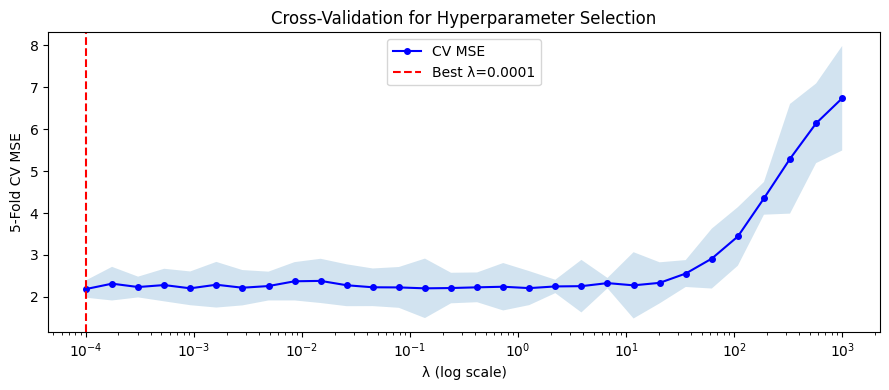

Best λ: 0.0001
CV MSE at best λ: 2.1859 ± 0.2066


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

rng = np.random.default_rng(0)

def kfold_indices(n: int, k: int, rng) -> list[tuple[np.ndarray, np.ndarray]]:
    """Returns list of (train_idx, val_idx) tuples for k-fold CV."""
    shuffled = rng.permutation(n)
    fold_size = n // k
    folds = []
    for i in range(k):
        val_idx   = shuffled[i*fold_size:(i+1)*fold_size]
        train_idx = np.concatenate([shuffled[:i*fold_size], shuffled[(i+1)*fold_size:]])
        folds.append((train_idx, val_idx))
    return folds

def cross_validate(
    X: np.ndarray,
    y: np.ndarray,
    model_fn,     # fn(X_tr, y_tr, X_val) -> y_pred_val
    metric_fn,    # fn(y_true, y_pred) -> float
    k: int = 5,
    rng = None,
) -> tuple[float, float]:
    """Returns (mean_score, std_score)."""
    if rng is None: rng = np.random.default_rng()
    folds  = kfold_indices(len(X), k, rng)
    scores = []
    for train_idx, val_idx in folds:
        y_pred = model_fn(X[train_idx], y[train_idx], X[val_idx])
        scores.append(metric_fn(y[val_idx], y_pred))
    return np.mean(scores), np.std(scores)

# Generate dataset
n = 200
X_raw = rng.normal(0, 1, (n, 5))
y_raw = 2 + X_raw @ np.array([1.5, -2.0, 0.5, 0, 0]) + rng.normal(0, 1.5, n)

# Ridge regression with different lambdas
lambdas = np.logspace(-4, 3, 30)
cv_means, cv_stds = [], []

def mse(y_true, y_pred): return np.mean((y_true - y_pred)**2)

for lam in lambdas:
    def model(X_tr, y_tr, X_val, _lam=lam):
        # Use ridge_regression from ch283 — here using sklearn to avoid copying
        m = Ridge(alpha=_lam, fit_intercept=True)
        m.fit(X_tr, y_tr)
        return m.predict(X_val)

    mu, sigma = cross_validate(X_raw, y_raw, model, mse, k=5, rng=rng)
    cv_means.append(mu)
    cv_stds.append(sigma)

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
best_lam = lambdas[np.argmin(cv_means)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lambdas, cv_means, 'b-o', ms=4, label='CV MSE')
ax.fill_between(lambdas, cv_means - cv_stds, cv_means + cv_stds, alpha=0.2)
ax.axvline(best_lam, color='red', ls='--', label=f'Best λ={best_lam:.4f}')
ax.set_xlabel('λ (log scale)')
ax.set_ylabel('5-Fold CV MSE')
ax.set_title('Cross-Validation for Hyperparameter Selection')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best λ: {best_lam:.4f}")
print(f"CV MSE at best λ: {cv_means.min():.4f} ± {cv_stds[np.argmin(cv_means)]:.4f}")

## 3. Leave-One-Out and Stratified K-Fold

In [2]:
def stratified_kfold_indices(
    y: np.ndarray, k: int, rng
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    For binary classification: ensure each fold has the same class ratio.
    """
    classes = np.unique(y)
    class_indices = [rng.permutation(np.where(y == c)[0]) for c in classes]

    folds_per_class = [np.array_split(idx, k) for idx in class_indices]
    folds = []
    for i in range(k):
        val_idx = np.concatenate([f[i] for f in folds_per_class])
        train_idx = np.concatenate([
            np.concatenate([f[j] for j in range(k) if j != i])
            for f in folds_per_class
        ])
        folds.append((train_idx, val_idx))
    return folds

# Verify class balance in stratified vs regular k-fold
y_imbalanced = np.array([1]*50 + [0]*150)
true_ratio   = y_imbalanced.mean()

regular_ratios     = []
stratified_ratios  = []

for train_idx, val_idx in kfold_indices(len(y_imbalanced), 5, rng):
    regular_ratios.append(y_imbalanced[val_idx].mean())

for train_idx, val_idx in stratified_kfold_indices(y_imbalanced, 5, rng):
    stratified_ratios.append(y_imbalanced[val_idx].mean())

print(f"True positive ratio:              {true_ratio:.3f}")
print(f"Regular k-fold fold ratios:       {[f'{r:.3f}' for r in regular_ratios]}")
print(f"Stratified k-fold fold ratios:    {[f'{r:.3f}' for r in stratified_ratios]}")

True positive ratio:              0.250
Regular k-fold fold ratios:       ['0.325', '0.125', '0.225', '0.250', '0.325']
Stratified k-fold fold ratios:    ['0.250', '0.250', '0.250', '0.250', '0.250']


## 4. What Comes Next

Cross-validation is the standard evaluation procedure for any ML system. **ch285 — A/B Testing** extends hypothesis testing to the setting where you compare two systems on live traffic, with the same concern for multiple comparisons that appeared in ch278. The full model selection workflow — CV for hyperparameters, held-out test set for final evaluation — is implemented in the project chapters ch298–299.